# FSRS4Anki Optimizer Benchmark

[![open in colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-spaced-repetition/fsrs4anki/blob/benchmark/benchmark.ipynb)

In [1]:
filename = "./revlog_history.tsv"

In [2]:
import zipfile
import sqlite3
import time
import pandas as pd
import numpy as np
import os
import math
from typing import List, Optional
from datetime import timedelta, datetime
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from torch import nn
from torch import Tensor
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from itertools import accumulate
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
tqdm.pandas()

In [3]:
df = pd.read_csv(filename, sep='\t')

df['retention'] = df.groupby(by=['r_history', 'delta_t'], group_keys=False)['y'].transform('mean')
df['total_cnt'] = df.groupby(by=['r_history', 'delta_t'], group_keys=False)['review_time'].transform('count')
print("Retention calculated.")

df.drop(columns=['review_time', 'card_id', 'review_duration', 'review_state', 'review_date', 'real_days', 'review_rating', 't_history', 'y'], inplace=True)
df.drop_duplicates(inplace=True)
df['retention'] = df['retention'].map(lambda x: max(min(0.99, x), 0.01))

def cal_stability(group: pd.DataFrame) -> pd.DataFrame:
    group_cnt = sum(group['total_cnt'])
    if group_cnt < 10:
        return pd.DataFrame()
    group['group_cnt'] = group_cnt
    if group['i'].values[0] > 1:
        r_ivl_cnt = sum(group['delta_t'] * group['retention'].map(np.log) * pow(group['total_cnt'], 2))
        ivl_ivl_cnt = sum(group['delta_t'].map(lambda x: x ** 2) * pow(group['total_cnt'], 2))
        group['stability'] = round(np.log(0.9) / (r_ivl_cnt / ivl_ivl_cnt), 1)
    else:
        group['stability'] = 0.0
    group['avg_retention'] = round(sum(group['retention'] * pow(group['total_cnt'], 2)) / sum(pow(group['total_cnt'], 2)), 3)
    group['avg_interval'] = round(sum(group['delta_t'] * pow(group['total_cnt'], 2)) / sum(pow(group['total_cnt'], 2)), 1)
    del group['total_cnt']
    del group['retention']
    del group['delta_t']
    return group

df = df.groupby(by=['r_history'], group_keys=False).progress_apply(cal_stability)
print("Stability calculated.")
df.reset_index(drop = True, inplace = True)
df.drop_duplicates(inplace=True)
df.sort_values(by=['r_history'], inplace=True, ignore_index=True)

if df.shape[0] > 0:
    for idx in tqdm(df.index, desc="analysis"):
        item = df.loc[idx]
        index = df[(df['i'] == item['i'] + 1) & (df['r_history'].str.startswith(item['r_history']))].index
        df.loc[index, 'last_stability'] = item['stability']
    df['factor'] = round(df['stability'] / df['last_stability'], 2)
    df = df[(df['i'] >= 2) & (df['group_cnt'] >= 100)].copy()
    df['last_recall'] = df['r_history'].map(lambda x: x[-1])
    df = df[df.groupby(['i', 'r_history'], group_keys=False)['group_cnt'].transform(max) == df['group_cnt']]
    df.to_csv('./stability_for_analysis.tsv', sep='\t', index=None)
    print("Analysis saved!")
    caption = "1:again, 2:hard, 3:good, 4:easy\n"
    analysis = df[df['r_history'].str.contains(r'^[1-4][^124]*$', regex=True)][['r_history', 'avg_interval', 'avg_retention', 'stability', 'factor', 'group_cnt']].to_string(index=False)
    print(caption + analysis)

Retention calculated.


  0%|          | 0/25030 [00:00<?, ?it/s]

Stability calculated.


analysis:   0%|          | 0/465 [00:00<?, ?it/s]

Analysis saved!
1:again, 2:hard, 3:good, 4:easy
      r_history  avg_interval  avg_retention  stability  factor  group_cnt
              1           1.1          0.892        1.0     NaN     1958.0
            1,3           3.1          0.920        4.0    4.00     1532.0
          1,3,3           7.1          0.911        7.6    1.90     1264.0
        1,3,3,3          16.5          0.862       10.5    1.38      947.0
      1,3,3,3,3          36.4          0.836       21.6    2.06      639.0
    1,3,3,3,3,3          75.6          0.858       35.5    1.64      348.0
  1,3,3,3,3,3,3         118.5          0.905       38.3    1.08      174.0
              2           1.0          0.901        1.0     NaN      192.0
            2,3           3.6          0.937        8.3    8.30      159.0
          2,3,3          12.7          0.858        4.7    0.57      125.0
              3           1.0          0.977        4.8     NaN     4258.0
            3,3           3.3          0.967       1

Weighted fit parameters: [1.13859448]
Number of reviews: 1958
RMSE: 0.0218


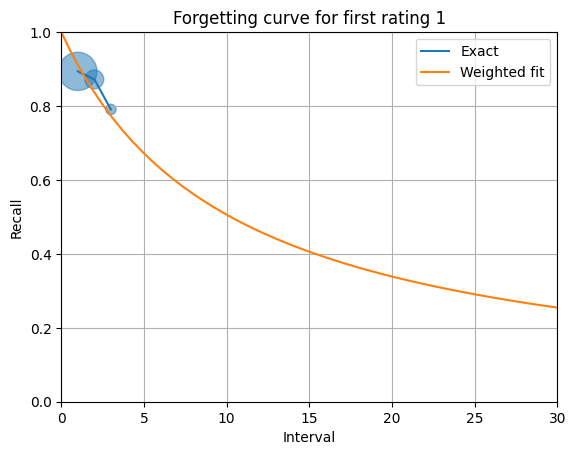

Weighted fit parameters: [1.01169591]
Number of reviews: 192
RMSE: 0.0000


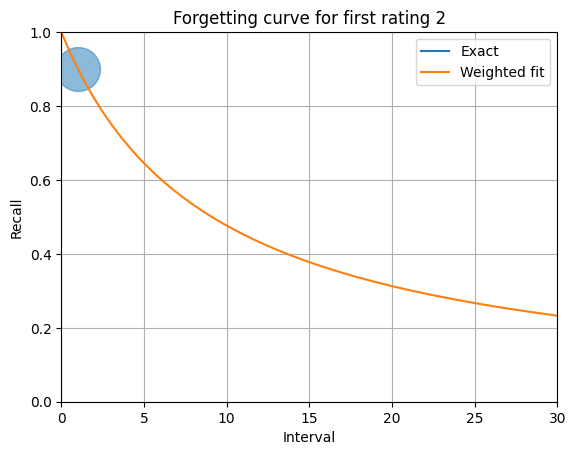

Weighted fit parameters: [5.45473494]
Number of reviews: 4258
RMSE: 0.0054


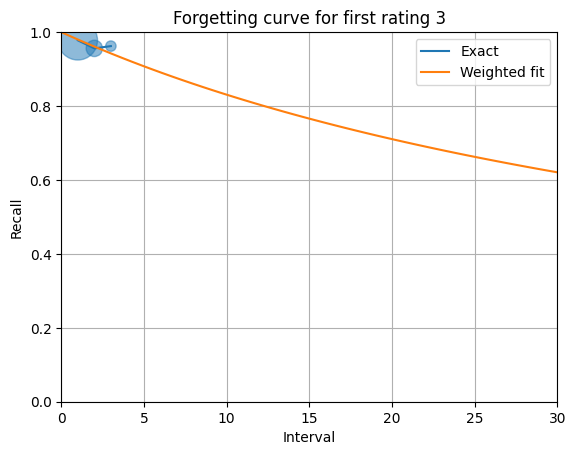

Weighted fit parameters: [14.90672308]
Number of reviews: 2753
RMSE: 0.0145


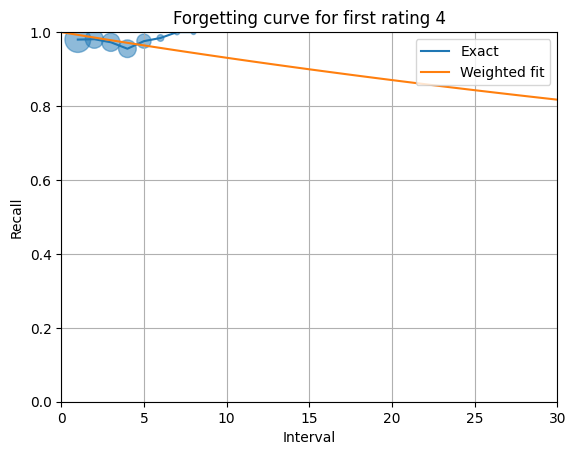

{1: 1.1385944809379058, 2: 1.0116959064438014, 3: 5.454734944907549, 4: 14.90672308187487}
Weighted fit parameters: [-1.6208471   1.07222787  0.49976575]
Fit stability: [ 1.07751274  2.18787419  5.43221912 14.91181161]
RMSE: 0.1553


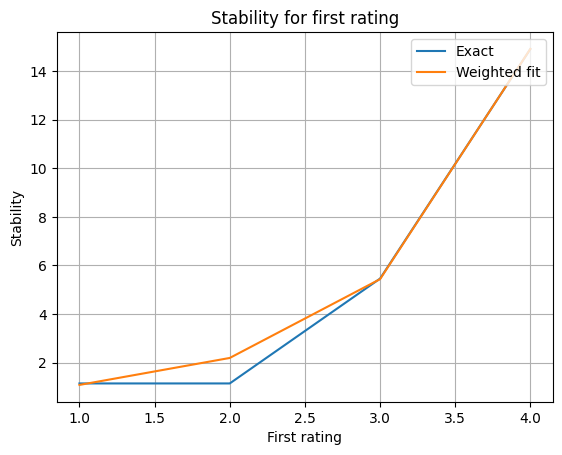

{1: 1.14, 2: 1.14, 3: 5.45, 4: 14.91}


In [4]:
from scipy.optimize import curve_fit

dataset = pd.read_csv(filename, sep='\t', index_col=None, dtype={'r_history': str ,'t_history': str} )
dataset = dataset[(dataset['i'] > 1) & (dataset['delta_t'] > 0) & (dataset['t_history'].str.count(',0') == 0)]
dataset['y'] = dataset['review_rating'].map({1: 0, 2: 1, 3: 1, 4: 1})
S0_dataset = dataset[dataset['i'] == 2]
S0_dataset_group = S0_dataset.groupby(by=['r_history', 'delta_t'], group_keys=False).agg({'y': ['mean', 'count']}).reset_index()

# we want to find the optimal S
def power_curve(delta_t, S):
    return (1 + delta_t / (9 * S)) ** -1
# def exp_curve(delta_t, S):
#     return np.exp(np.log(0.9) * delta_t / S)

rating_stability = {}
rating_count = {}
reviews_in_collection = len(dataset)

for first_rating in ("1", "2", "3", "4"):
    group = S0_dataset_group[S0_dataset_group['r_history'] == first_rating]
    if group.empty:
        continue
    delta_t = group['delta_t']
    recall = group['y']['mean']
    count = group['y']['count']
    if sum(count) < 100:
        continue
    params, covs = curve_fit(power_curve, delta_t, recall, sigma=1/np.sqrt(count), bounds=((0.1), (3650)))
    rating_stability[int(first_rating)] = params[0]
    rating_count[int(first_rating)] = sum(count)
    print('Weighted fit parameters:', params)
    print('Number of reviews:', sum(count))
    predict_recall = power_curve(delta_t, *params)
    print(f'RMSE: {mean_squared_error(recall, predict_recall, sample_weight=count, squared=False):.4f}')

    plt.plot(delta_t, recall, label='Exact')
    plt.plot(np.linspace(0, 30), power_curve(np.linspace(0, 30), *params), label='Weighted fit')
    count_percent = np.array([x/sum(count) for x in count])
    plt.scatter(delta_t, recall, s=count_percent * 1000, alpha=0.5)
    plt.legend(loc='upper right', fancybox=True, shadow=False)
    plt.grid(True)
    plt.ylim(0, 1)
    plt.xlim(0, 30)
    plt.xlabel('Interval')
    plt.ylabel('Recall')
    plt.title('Forgetting curve for first rating ' + first_rating)
    plt.show()

print(rating_stability)
for a, b in ((1, 2), (2, 3), (3, 4)):
    if a in rating_stability and b in rating_stability:
        if rating_stability[a] > rating_stability[b]:
            if rating_count[a] > rating_count[b]:
                rating_stability[b] = rating_stability[a]
            else:
                rating_stability[a] = rating_stability[b]

def S0_rating_curve(rating, a, b, c):
    return np.exp(a + b * rating) + c

params, covs = curve_fit(S0_rating_curve, list(rating_stability.keys()), list(rating_stability.values()), sigma=1/np.sqrt(list(rating_count.values())), method='dogbox', bounds=((-15, 0.03, -5), (15, 7, 30)))
print('Weighted fit parameters:', params)
predict_stability = S0_rating_curve(np.array(list(rating_stability.keys())), *params)
print("Fit stability:", predict_stability)
print(f'RMSE: {mean_squared_error(list(rating_stability.values()), predict_stability, sample_weight=list(rating_count.values()), squared=False):.4f}')
plt.plot(list(rating_stability.keys()), list(rating_stability.values()), label='Exact')
plt.plot(list(rating_stability.keys()), predict_stability, label='Weighted fit')
plt.legend(loc='upper right', fancybox=True, shadow=False)
plt.grid(True)
plt.xlabel('First rating')
plt.ylabel('Stability')
plt.title('Stability for first rating')
plt.show()

for rating in (1, 2, 3, 4):
    again_extrap = max(min(S0_rating_curve(1, *params), 3650), 0.1)
    # if there isn't enough data to calculate the value for "Again" exactly
    if 1 not in rating_stability:
        # then check if there exists an exact value for "Hard"
        if 2 in rating_stability:
            # if it exists, then check whether the extrapolation breaks monotonicity
            # Again > Hard is possible, but we should allow it only for exact values, otherwise we should assume monotonicity
            if again_extrap > rating_stability[2]:
                # if it does, then replace the missing "Again" value with the exact "Hard" value
                rating_stability[1] = rating_stability[2]
            else:
                # if it doesn't break monotonicity, then use the extrapolated value
                rating_stability[1] = again_extrap
        # if an exact value for "Hard" doesn't exist, then just use the extrapolation, there's nothing else we can do
        else:
            rating_stability[1] = again_extrap
    elif rating not in rating_stability:
        rating_stability[rating] = max(min(S0_rating_curve(rating, *params), 3650), 0.1)

rating_stability = {k: round(v, 2) for k, v in sorted(rating_stability.items(), key=lambda item: item[0])}

print(rating_stability)

In [5]:
class FSRS3WeightClipper:
    def __init__(self, frequency: int=1):
        self.frequency = frequency

    def __call__(self, module):
        if hasattr(module, 'w'):
            w = module.w.data
            w[0] = w[0].clamp(0.1, 10)
            w[1] = w[1].clamp(0.1, 5)
            w[2] = w[2].clamp(1, 10)
            w[3] = w[3].clamp(-5, -0.1)
            w[4] = w[4].clamp(-5, -0.1)
            w[5] = w[5].clamp(0.05, 0.5)
            w[6] = w[6].clamp(0, 2)
            w[7] = w[7].clamp(-0.8, -0.15)
            w[8] = w[8].clamp(0.01, 1.5)
            w[9] = w[9].clamp(0.5, 5)
            w[10] = w[10].clamp(-2, -0.01)
            w[11] = w[11].clamp(0.01, 0.9)
            w[12] = w[12].clamp(0.01, 2)
            module.w.data = w

class FSRS3(nn.Module):
    init_w = [1, 1, 5, -0.5, -0.5, 0.2, 1.4, -0.2, 0.8, 2, -0.2, 0.2, 1]
    clipper = FSRS3WeightClipper()
    def __init__(self, w: List[float] = init_w):
        super(FSRS3, self).__init__()
        self.w = nn.Parameter(torch.tensor(w, dtype=torch.float32))

    def forgetting_curve(self, t, s):
        return 0.9 ** (t / s)

    def stability_after_success(self, state: Tensor, new_d: Tensor, r: Tensor) -> Tensor:
        new_s = state[:,0] * (1 + torch.exp(self.w[6]) *
                        (11 - new_d) *
                        torch.pow(state[:,0], self.w[7]) *
                        (torch.exp((1 - r) * self.w[8]) - 1))
        return new_s

    def stability_after_failure(self, state: Tensor, new_d: Tensor, r: Tensor) -> Tensor:
        new_s = self.w[9] * torch.pow(new_d, self.w[10]) * torch.pow(
            state[:,0], self.w[11]) * torch.exp((1 - r) * self.w[12])
        return new_s

    def step(self, X: Tensor, state: Tensor) -> Tensor:
        '''
        :param X: shape[batch_size, 2], X[:,0] is elapsed time, X[:,1] is rating
        :param state: shape[batch_size, 2], state[:,0] is stability, state[:,1] is difficulty
        :return state:
        '''
        if torch.equal(state, torch.zeros_like(state)):
            # first learn, init memory states
            new_s = self.w[0] + self.w[1] * (X[:,1] - 1)
            new_d = self.w[2] + self.w[3] * (X[:,1] - 3)
            new_d = new_d.clamp(1, 10)
        else:
            r = self.forgetting_curve(X[:,0], state[:,0])
            new_d = state[:,1] + self.w[4] * (X[:,1] - 3)
            new_d = self.mean_reversion(self.w[2], new_d)
            new_d = new_d.clamp(1, 10)
            condition = X[:,1] > 1
            new_s = torch.where(condition, self.stability_after_success(state, new_d, r), self.stability_after_failure(state, new_d, r))
        new_s = new_s.clamp(0.1, 36500)
        return torch.stack([new_s, new_d], dim=1)

    def forward(self, inputs: Tensor, state: Optional[Tensor]=None) -> Tensor:
        '''
        :param inputs: shape[seq_len, batch_size, 2]
        '''
        if state is None:
            state = torch.zeros((inputs.shape[1], 2))
        outputs = []
        for X in inputs:
            state = self.step(X, state)
            outputs.append(state)
        return torch.stack(outputs), state

    def mean_reversion(self, init: Tensor, current: Tensor) -> Tensor:
        return self.w[5] * init + (1-self.w[5]) * current
    


class FSRS4WeightClipper:
    def __init__(self, frequency: int=1):
        self.frequency = frequency

    def __call__(self, module):
        if hasattr(module, 'w'):
            w = module.w.data
            w[0] = w[0].clamp(0.1, 10)
            w[1] = w[1].clamp(0.1, 5)
            w[2] = w[2].clamp(1, 10)
            w[3] = w[3].clamp(-5, -0.1)
            w[4] = w[4].clamp(-5, -0.1)
            w[5] = w[5].clamp(0, 0.5)
            w[6] = w[6].clamp(0, 2)
            w[7] = w[7].clamp(-0.8, -0.1)
            w[8] = w[8].clamp(0.01, 1.5)
            w[9] = w[9].clamp(0.5, 5)
            w[10] = w[10].clamp(-2, -0.01)
            w[11] = w[11].clamp(0.01, 0.9)
            w[12] = w[12].clamp(0.01, 2)
            w[13] = w[13].clamp(0, 1)
            w[14] = w[14].clamp(1, 10)
            module.w.data = w


class FSRS4(nn.Module):
    init_w = [1, 1, 4.93, -0.94, -0.86, 0.01, 1.49, -0.14, 0.94, 2.18, -0.05, 0.34, 1.26, 0.29, 2.61]
    clipper = FSRS4WeightClipper()
    def __init__(self, w: List[float] = init_w):
        super(FSRS4, self).__init__()
        self.w = nn.Parameter(torch.tensor(w, dtype=torch.float32))
        self.s0 = torch.zeros(4)
        for i in range(4):
            if i+1 in rating_stability:
                self.s0[i] = rating_stability[i+1]

    def forgetting_curve(self, t, s):
        return (1 + t / (9 * s)) ** -1

    def stability_after_success(self, state: Tensor, new_d: Tensor, r: Tensor, rating: Tensor) -> Tensor:
        hard_bonus = torch.where(rating == 2, self.w[13], 1)
        easy_bonus = torch.where(rating == 4, self.w[14], 1)
        new_s = state[:,0] * (1 + torch.exp(self.w[6]) *
                        (11 - new_d) *
                        torch.pow(state[:,0], self.w[7]) *
                        (torch.exp((1 - r) * self.w[8]) - 1) * hard_bonus * easy_bonus)
        return new_s

    def stability_after_failure(self, state: Tensor, new_d: Tensor, r: Tensor) -> Tensor:
        new_s = self.w[9] * \
                torch.pow(new_d, self.w[10]) * \
                (torch.pow(state[:,0] + 1, self.w[11]) - 1) * \
                torch.exp((1 - r) * self.w[12])
        return new_s

    def step(self, X: Tensor, state: Tensor) -> Tensor:
        '''
        :param X: shape[batch_size, 2], X[:,0] is elapsed time, X[:,1] is rating
        :param state: shape[batch_size, 2], state[:,0] is stability, state[:,1] is difficulty
        :return state:
        '''
        if torch.equal(state, torch.zeros_like(state)):
            keys = torch.tensor([1, 2, 3, 4])
            keys = keys.view(1, -1).expand(X[:,1].long().size(0), -1)
            index = (X[:,1].long().unsqueeze(1) == keys).nonzero(as_tuple=True)
            # first learn, init memory states
            new_s = self.s0[index[1]]
            new_d = self.w[2] + self.w[3] * (X[:,1] - 3)
            new_d = new_d.clamp(1, 10)
        else:
            r = self.forgetting_curve(X[:,0], state[:,0])
            new_d = state[:,1] + self.w[4] * (X[:,1] - 3)
            new_d = self.mean_reversion(self.w[2], new_d)
            new_d = new_d.clamp(1, 10)
            condition = X[:,1] > 1
            new_s = torch.where(condition, self.stability_after_success(state, new_d, r, X[:,1]), self.stability_after_failure(state, new_d, r))
        new_s = new_s.clamp(0.1, 36500)
        return torch.stack([new_s, new_d], dim=1)

    def forward(self, inputs: Tensor, state: Optional[Tensor]=None) -> Tensor:
        '''
        :param inputs: shape[seq_len, batch_size, 2]
        '''
        if state is None:
            state = torch.zeros((inputs.shape[1], 2))
        outputs = []
        for X in inputs:
            state = self.step(X, state)
            outputs.append(state)
        return torch.stack(outputs), state

    def mean_reversion(self, init: Tensor, current: Tensor) -> Tensor:
        return self.w[5] * init + (1-self.w[5]) * current

n_input=5
n_hidden=8
n_output=1
n_layers=1
network="LSTM"
class RNN(nn.Module):
    def __init__(self, state_dict=None):
        super().__init__()
        self.n_input = n_input
        self.n_hidden = n_hidden
        self.n_out = n_output
        self.n_layers = n_layers
        if network == 'GRU':
            self.rnn = nn.GRU(input_size=self.n_input, hidden_size=self.n_hidden, num_layers=self.n_layers)
        elif network == "LSTM":
            self.rnn = nn.LSTM(input_size=self.n_input, hidden_size=self.n_hidden, num_layers=self.n_layers)
        else:
            self.rnn = nn.RNN(input_size=self.n_input, hidden_size=self.n_hidden, num_layers=self.n_layers)

        self.fc = nn.Linear(self.n_hidden, self.n_out)

        if state_dict is not None:
            self.load_state_dict(state_dict)

    def forward(self, x, hx=None):
        x, h = self.rnn(x, hx=hx)
        output = torch.exp(self.fc(x))
        return output, h

    def full_connect(self, h):
        return self.fc(h)

    def forgetting_curve(self, t, s):
        return 0.9 ** (t / s)

def lineToTensor(line: str) -> Tensor:
    ivl = line[0].split(',')
    response = line[1].split(',')
    tensor = torch.zeros(len(response), 2)
    for li, response in enumerate(response):
        tensor[li][0] = int(ivl[li])
        tensor[li][1] = int(response)
    return tensor

def lineToTensorRNN(line):
    ivl = line[0].split(',')
    response = line[1].split(',')
    tensor = torch.zeros(len(response), 5, dtype=torch.float32)
    for li, response in enumerate(response):
        tensor[li][0] = int(ivl[li])
        tensor[li][int(response)] = 1
    return tensor

class RevlogDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame):
        if dataframe.empty:
            raise ValueError('Training data is inadequate.')
        self.x_train = pad_sequence(dataframe['tensor'].to_list(), batch_first=True, padding_value=0)
        self.t_train = torch.tensor(dataframe['delta_t'].values, dtype=torch.int)
        self.y_train = torch.tensor(dataframe['y'].values, dtype=torch.float)
        self.seq_len = torch.tensor(dataframe['tensor'].map(len).values, dtype=torch.long)

    def __getitem__(self, idx):
        return self.x_train[idx], self.t_train[idx], self.y_train[idx], self.seq_len[idx]

    def __len__(self):
        return len(self.y_train)

class RevlogSampler(Sampler[List[int]]):
    def __init__(self, data_source: RevlogDataset, batch_size: int):
        self.data_source = data_source
        self.batch_size = batch_size
        lengths = np.array(data_source.seq_len)
        indices = np.argsort(lengths)
        full_batches, remainder = divmod(indices.size, self.batch_size)
        if full_batches > 0:
            if remainder == 0:
                self.batch_indices = np.split(indices, full_batches)
            else:
                self.batch_indices = np.split(indices[:-remainder], full_batches)
        else:
            self.batch_indices = []
        if remainder > 0:
            self.batch_indices.append(indices[-remainder:])
        self.batch_nums = len(self.batch_indices)
        # seed = int(torch.empty((), dtype=torch.int64).random_().item())
        seed = 2023
        self.generator = torch.Generator()
        self.generator.manual_seed(seed)

    def __iter__(self):
        yield from (self.batch_indices[idx] for idx in torch.randperm(self.batch_nums, generator=self.generator).tolist())

    def __len__(self):
        return len(self.data_source)


def collate_fn(batch):
    sequences, delta_ts, labels, seq_lens = zip(*batch)
    sequences_packed = pack_padded_sequence(torch.stack(sequences, dim=1), lengths=torch.stack(seq_lens), batch_first=False, enforce_sorted=False)
    sequences_padded, length = pad_packed_sequence(sequences_packed, batch_first=False)
    sequences_padded = torch.as_tensor(sequences_padded)
    seq_lens = torch.as_tensor(length)
    delta_ts = torch.as_tensor(delta_ts)
    labels = torch.as_tensor(labels)
    return sequences_padded, delta_ts, labels, seq_lens

class Trainer:
    def __init__(self, MODEL: nn.Module, train_set: pd.DataFrame, test_set: pd.DataFrame, n_epoch: int=1, lr: float=1e-2, batch_size: int=256) -> None:
        self.model = MODEL
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.clipper = MODEL.clipper if not isinstance(MODEL, RNN) else None
        self.batch_size = batch_size
        self.build_dataset(train_set, test_set)
        self.n_epoch = n_epoch
        self.batch_nums = self.next_train_data_loader.batch_sampler.batch_nums
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=self.batch_nums * n_epoch)
        self.avg_train_losses = []
        self.avg_eval_losses = []
        self.loss_fn = nn.BCELoss(reduction='none')

    def build_dataset(self, train_set: pd.DataFrame, test_set: pd.DataFrame):
        pre_train_set = train_set[train_set['i'] == 2]
        self.pre_train_set = RevlogDataset(pre_train_set)
        sampler = RevlogSampler(self.pre_train_set, batch_size=self.batch_size)
        self.pre_train_data_loader = DataLoader(self.pre_train_set, batch_sampler=sampler, collate_fn=collate_fn)

        next_train_set = train_set[train_set['i'] > 2]
        self.next_train_set = RevlogDataset(next_train_set)
        sampler = RevlogSampler(self.next_train_set, batch_size=self.batch_size)
        self.next_train_data_loader = DataLoader(self.next_train_set, batch_sampler=sampler, collate_fn=collate_fn)

        self.train_set = RevlogDataset(train_set)
        sampler = RevlogSampler(self.train_set, batch_size=self.batch_size)
        self.train_data_loader = DataLoader(self.train_set, batch_sampler=sampler, collate_fn=collate_fn)

        self.test_set = RevlogDataset(test_set)
        sampler = RevlogSampler(self.test_set, batch_size=self.batch_size)
        self.test_data_loader = DataLoader(self.test_set, batch_sampler=sampler, collate_fn=collate_fn)
        print("dataset built")

    def train(self, verbose: bool=True):
        best_loss = np.inf

        if isinstance(self.model, RNN):
            epoch_len = len(self.train_data_loader)
            pbar = tqdm(desc="train", colour="red", total=epoch_len*self.n_epoch)
            print_len = max(self.batch_nums*self.n_epoch // 5, 1)
            for k in range(self.n_epoch):
                weighted_loss = self.eval()
                for i, batch in enumerate(self.train_data_loader):
                    self.model.train()
                    self.optimizer.zero_grad()
                    sequences, delta_ts, labels, seq_lens = batch
                    real_batch_size = seq_lens.shape[0]
                    outputs, _ = self.model(sequences)
                    stabilities = outputs[seq_lens-1, torch.arange(real_batch_size), 0]
                    retentions = self.model.forgetting_curve(delta_ts, stabilities)
                    loss = self.loss_fn(retentions, labels).sum()
                    loss.backward()
                    self.optimizer.step()
                    self.scheduler.step()
                    pbar.update(real_batch_size)
            return self.model.state_dict()

        if isinstance(self.model, FSRS3):
            for k in range(self.n_epoch):
                for i, batch in enumerate(self.pre_train_data_loader):
                    self.model.train()
                    self.optimizer.zero_grad()
                    sequences, delta_ts, labels, seq_lens = batch
                    real_batch_size = seq_lens.shape[0]
                    outputs, _ = self.model(sequences)
                    stabilities = outputs[seq_lens-1, torch.arange(real_batch_size), 0]
                    retentions = self.model.forgetting_curve(delta_ts, stabilities)
                    loss = self.loss_fn(retentions, labels).sum()
                    loss.backward()
                    self.optimizer.step()
                    self.model.apply(self.clipper)

        epoch_len = len(self.next_train_data_loader)
        pbar = tqdm(desc="train", colour="red", total=epoch_len*self.n_epoch)
        print_len = max(self.batch_nums*self.n_epoch // 10, 1)
        for k in range(self.n_epoch):
            weighted_loss, w = self.eval()
            if weighted_loss < best_loss:
                best_loss = weighted_loss
                best_w = w

            for i, batch in enumerate(self.next_train_data_loader):
                self.model.train()
                self.optimizer.zero_grad()
                sequences, delta_ts, labels, seq_lens = batch
                real_batch_size = seq_lens.shape[0]
                outputs, _ = self.model(sequences)
                stabilities = outputs[seq_lens-1, torch.arange(real_batch_size), 0]
                retentions = self.model.forgetting_curve(delta_ts, stabilities)
                loss = self.loss_fn(retentions, labels).sum()
                loss.backward()
                for param in self.model.parameters():
                    param.grad[:2] = torch.zeros(2)
                self.optimizer.step()
                self.scheduler.step()
                self.model.apply(self.clipper)
                pbar.update(real_batch_size)

                if verbose and (k * self.batch_nums + i + 1) % print_len == 0:
                    tqdm.write(f"iteration: {k * epoch_len + (i + 1) * self.batch_size}")
                    for name, param in self.model.named_parameters():
                        tqdm.write(f"{name}: {list(map(lambda x: round(float(x), 4),param))}")
        pbar.close()

        weighted_loss, w = self.eval()
        if weighted_loss < best_loss:
            best_loss = weighted_loss
            best_w = w

        return best_w

    def eval(self):
        self.model.eval()
        with torch.no_grad():
            sequences, delta_ts, labels, seq_lens = self.train_set.x_train, self.train_set.t_train, self.train_set.y_train, self.train_set.seq_len
            real_batch_size = seq_lens.shape[0]
            outputs, _ = self.model(sequences.transpose(0, 1))
            stabilities = outputs[seq_lens-1, torch.arange(real_batch_size), 0]
            retentions = self.model.forgetting_curve(delta_ts, stabilities)
            tran_loss = self.loss_fn(retentions, labels).mean()
            self.avg_train_losses.append(tran_loss)

            sequences, delta_ts, labels, seq_lens = self.test_set.x_train, self.test_set.t_train, self.test_set.y_train, self.test_set.seq_len
            real_batch_size = seq_lens.shape[0]
            outputs, _ = self.model(sequences.transpose(0, 1))
            stabilities = outputs[seq_lens-1, torch.arange(real_batch_size), 0]
            retentions = self.model.forgetting_curve(delta_ts, stabilities)
            test_loss = self.loss_fn(retentions, labels).mean()
            self.avg_eval_losses.append(test_loss)

            if isinstance(self.model, RNN):
                w = self.model.state_dict()
            else:
                w = list(map(lambda x: round(float(x), 4), dict(self.model.named_parameters())['w'].data))

            weighted_loss = (tran_loss * len(self.train_set) + test_loss * len(self.test_set)) / (len(self.train_set) + len(self.test_set))

            return weighted_loss, w

    def plot(self):
        fig = plt.figure()
        ax = fig.gca()
        ax.plot(self.avg_train_losses, label='train')
        ax.plot(self.avg_eval_losses, label='test')
        ax.set_xlabel('epoch')
        ax.set_ylabel('loss')
        ax.legend()
        return fig
    
class Collection:
    def __init__(self, MDOEL) -> None:
        self.model = MDOEL
        self.model.eval()

    def predict(self, t_history: str, r_history: str):
        with torch.no_grad():
            if isinstance(self.model, RNN):
                line_tensor = lineToTensorRNN(list(zip([t_history], [r_history]))[0]).unsqueeze(1)
            else:
                line_tensor = lineToTensor(list(zip([t_history], [r_history]))[0]).unsqueeze(1)
            output_t = self.model(line_tensor)
            return output_t[-1][0]

    def batch_predict(self, dataset):
        fast_dataset = RevlogDataset(dataset)
        with torch.no_grad():
            outputs, _ = self.model(fast_dataset.x_train.transpose(0, 1))
            if isinstance(self.model, RNN):
                stabilities = outputs[fast_dataset.seq_len-1, torch.arange(len(fast_dataset))].transpose(0, 1)[0]
            else:
                stabilities, _ = outputs[fast_dataset.seq_len-1, torch.arange(len(fast_dataset))].transpose(0, 1)
            return stabilities.tolist()
        
# code from https://github.com/papousek/duolingo-halflife-regression/blob/master/evaluation.py
def load_brier(predictions, real, bins=20):
    counts = np.zeros(bins)
    correct = np.zeros(bins)
    prediction = np.zeros(bins)
    for p, r in zip(predictions, real):
        bin = min(int(p * bins), bins - 1)
        counts[bin] += 1
        correct[bin] += r
        prediction[bin] += p
    np.seterr(invalid='ignore')
    prediction_means = prediction / counts
    prediction_means[np.isnan(prediction_means)] = ((np.arange(bins) + 0.5) / bins)[np.isnan(prediction_means)]
    correct_means = correct / counts
    correct_means[np.isnan(correct_means)] = 0
    size = len(predictions)
    answer_mean = sum(correct) / size
    return {
        "reliability": sum(counts * (correct_means - prediction_means) ** 2) / size,
        "resolution": sum(counts * (correct_means - answer_mean) ** 2) / size,
        "uncertainty": answer_mean * (1 - answer_mean),
        "detail": {
            "bin_count": bins,
            "bin_counts": list(counts),
            "bin_prediction_means": list(prediction_means),
            "bin_correct_means": list(correct_means),
        }
    }


def plot_brier(predictions, real, bins=20):
    brier = load_brier(predictions, real, bins=bins)
    bin_prediction_means = brier['detail']['bin_prediction_means']
    bin_correct_means = brier['detail']['bin_correct_means']
    bin_counts = brier['detail']['bin_counts']
    r2 = r2_score(bin_correct_means, bin_prediction_means, sample_weight=bin_counts)
    rmse = mean_squared_error(bin_correct_means, bin_prediction_means, sample_weight=bin_counts, squared=False)
    mae = mean_absolute_error(bin_correct_means, bin_prediction_means, sample_weight=bin_counts)
    print(f"R-squared: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    tqdm.write(f"MAE: {mae:.4f}")
    ax = plt.gca()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    plt.grid(True)
    fit_wls = sm.WLS(bin_correct_means, sm.add_constant(bin_prediction_means), weights=bin_counts).fit()
    print(fit_wls.params)
    y_regression = [fit_wls.params[0] + fit_wls.params[1]*x for x in bin_prediction_means]
    plt.plot(bin_prediction_means, y_regression, label='Weighted Least Squares Regression', color="green")
    plt.plot(bin_prediction_means, bin_correct_means, label='Actual Calibration', color="#1f77b4")
    plt.plot((0, 1), (0, 1), label='Perfect Calibration', color="#ff7f0e")
    bin_count = brier['detail']['bin_count']
    counts = np.array(bin_counts)
    bins = (np.arange(bin_count) + 0.5) / bin_count
    plt.legend(loc='upper center')
    plt.xlabel('Predicted R')
    plt.ylabel('Actual R')
    plt.twinx()
    plt.ylabel('Number of reviews')
    plt.bar(bins, counts, width=(0.8 / bin_count), ec='k', lw=.2, alpha=0.5, label='Number of reviews')
    plt.legend(loc='lower center')


  0%|          | 0/83598 [00:00<?, ?it/s]

Tensorized!
dataset built


train:   0%|          | 0/417990 [00:00<?, ?it/s]


Training finished!
Total parameters: 489
loss before: 2.3557, loss after: 0.3025, improvement: 2.0532
R-squared: 0.9274
RMSE: 0.0208
MAE: 0.0070
[0.14578129 0.84052649]


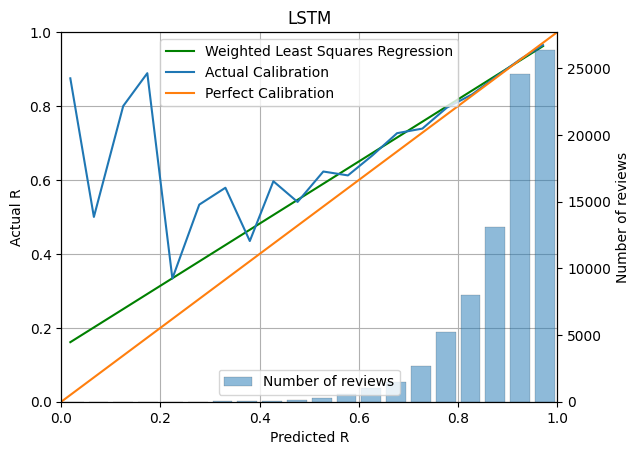


Last rating: 1
R-squared: 0.1678
RMSE: 0.0433
MAE: 0.0205
[0.40037061 0.54391998]

Last rating: 2
R-squared: 0.6684
RMSE: 0.0463
MAE: 0.0306
[0.28179783 0.67561976]

Last rating: 3
R-squared: 0.9600
RMSE: 0.0160
MAE: 0.0062
[0.088245   0.90612341]

Last rating: 4
R-squared: 0.2197
RMSE: 0.0235
MAE: 0.0110
[0.43157128 0.5532352 ]


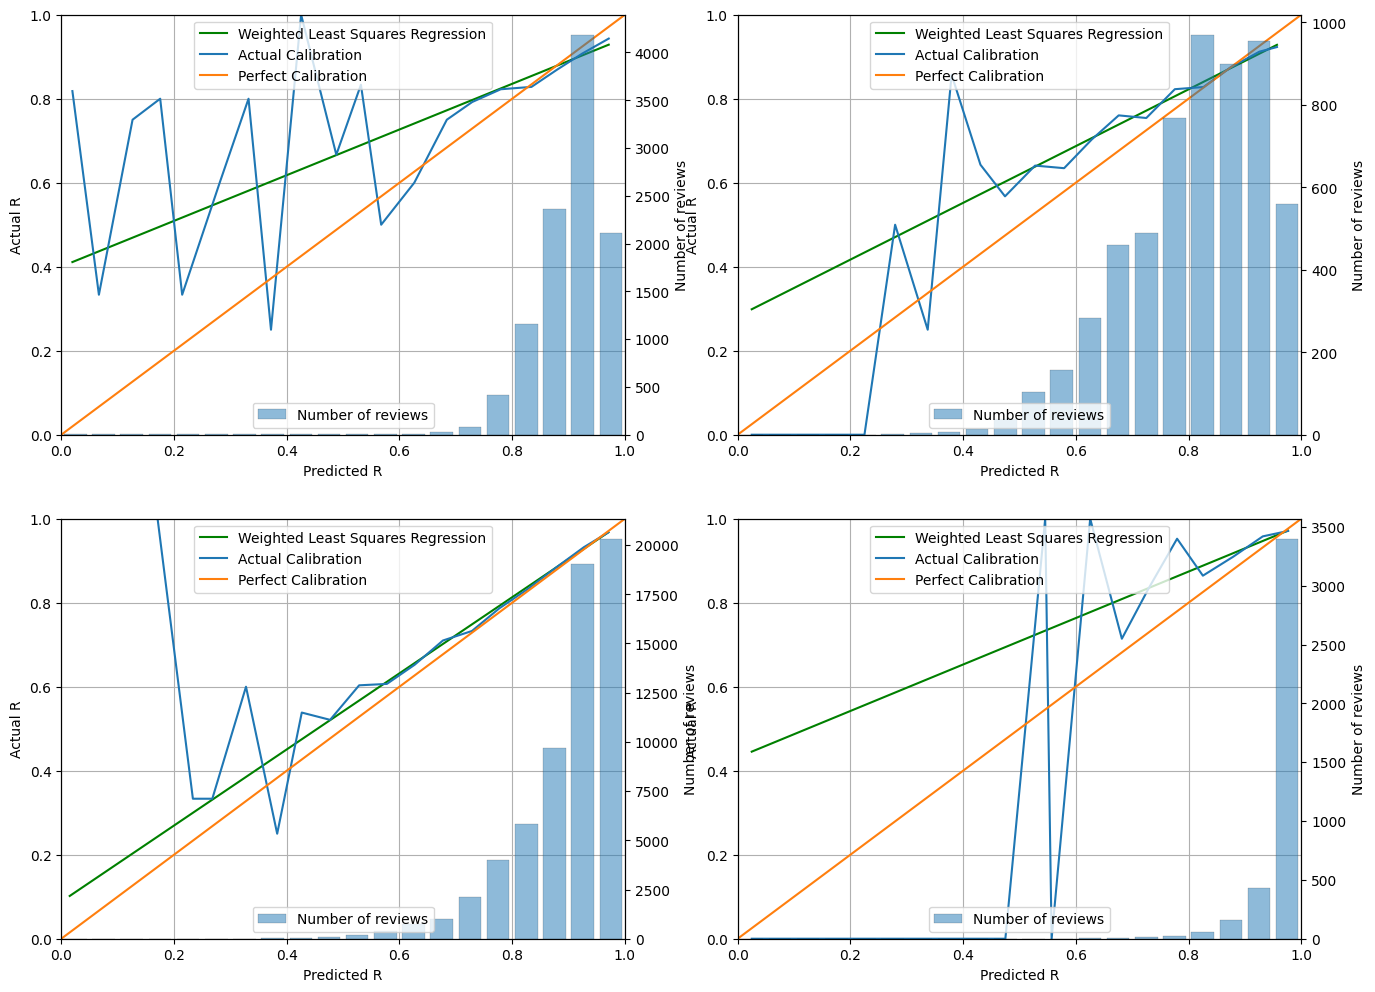

In [6]:
lr: float = 4e-2
n_epoch: int = 5
n_splits: int = 1
batch_size: int = 512
verbose: bool = False

model = RNN

dataset = pd.read_csv("./revlog_history.tsv", sep='\t', index_col=None, dtype={'r_history': str ,'t_history': str} )
dataset = dataset[(dataset['i'] > 1) & (dataset['delta_t'] > 0) & (dataset['t_history'].str.count(',0') == 0)]
if dataset.empty:
    raise ValueError('Training data is inadequate.')

if model == RNN:
    dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensorRNN(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)
else:
    dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensor(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)
dataset['group'] = dataset['r_history'] + dataset['t_history']
print("Tensorized!")

lstm_w = []
plots = []
if n_splits > 1:
    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    for train_index, test_index in sgkf.split(dataset, dataset['i'], dataset['group']):
        print("TRAIN:", len(train_index), "TEST:",  len(test_index))
        train_set = dataset.iloc[train_index].copy()
        test_set = dataset.iloc[test_index].copy()
        trainer = Trainer(model(), train_set, test_set, n_epoch=n_epoch, lr=lr, batch_size=batch_size)
        lstm_w.append(trainer.train(verbose=verbose))
        # plots.append(trainer.plot())
else:
    trainer = Trainer(model(), dataset, dataset, n_epoch=n_epoch, lr=lr, batch_size=batch_size)
    lstm_w.append(trainer.train(verbose=verbose))
    # plots.append(trainer.plot())

lstm_w = lstm_w[-1]

print("\nTraining finished!")

total_params = sum(p.numel() for p in lstm_w.values())
print(f"Total parameters: {total_params}")

my_collection = Collection(model())
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss_before = dataset['log_loss'].mean()

my_collection = Collection(model(lstm_w))
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss_after = dataset['log_loss'].mean()
print(f"loss before: {loss_before:.4f}, loss after: {loss_after:.4f}, improvement: {loss_before - loss_after:.4f}")

plot_brier(dataset['p'], dataset['y'], bins=20)
plt.title("LSTM")
plt.show()
plt.figure(figsize=(16, 12))
for last_rating in ("1","2","3","4"):
    calibration_data = dataset[dataset['r_history'].str.endswith(last_rating)]
    if calibration_data.empty:
        continue
    plt.subplot(2, 2, int(last_rating))
    print(f"\nLast rating: {last_rating}")
    plot_brier(calibration_data['p'], calibration_data['y'], bins=20)

  0%|          | 0/83598 [00:00<?, ?it/s]

Tensorized!
TRAIN: 54591 TEST: 29007
dataset built


train:   0%|          | 0/149064 [00:00<?, ?it/s]

TRAIN: 56533 TEST: 27065
dataset built


train:   0%|          | 0/148566 [00:00<?, ?it/s]

TRAIN: 56072 TEST: 27526
dataset built


train:   0%|          | 0/148992 [00:00<?, ?it/s]


Training finished!
loss before: 0.3245, loss after: 0.3077, improvement: 0.0168
R-squared: 0.9466
RMSE: 0.0162
MAE: 0.0050
[0.0789043  0.91288007]


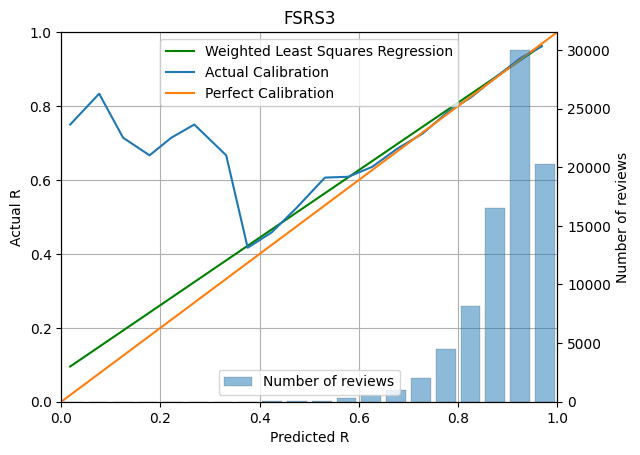


Last rating: 1
R-squared: 0.3795
RMSE: 0.0417
MAE: 0.0265
[0.30650435 0.64027391]

Last rating: 2
R-squared: -0.7870
RMSE: 0.0973
MAE: 0.0929
[-0.64992776  1.60451413]

Last rating: 3
R-squared: 0.9399
RMSE: 0.0189
MAE: 0.0118
[0.02384791 0.98620569]

Last rating: 4
R-squared: -0.6544
RMSE: 0.0365
MAE: 0.0212
[0.5110117  0.48049368]


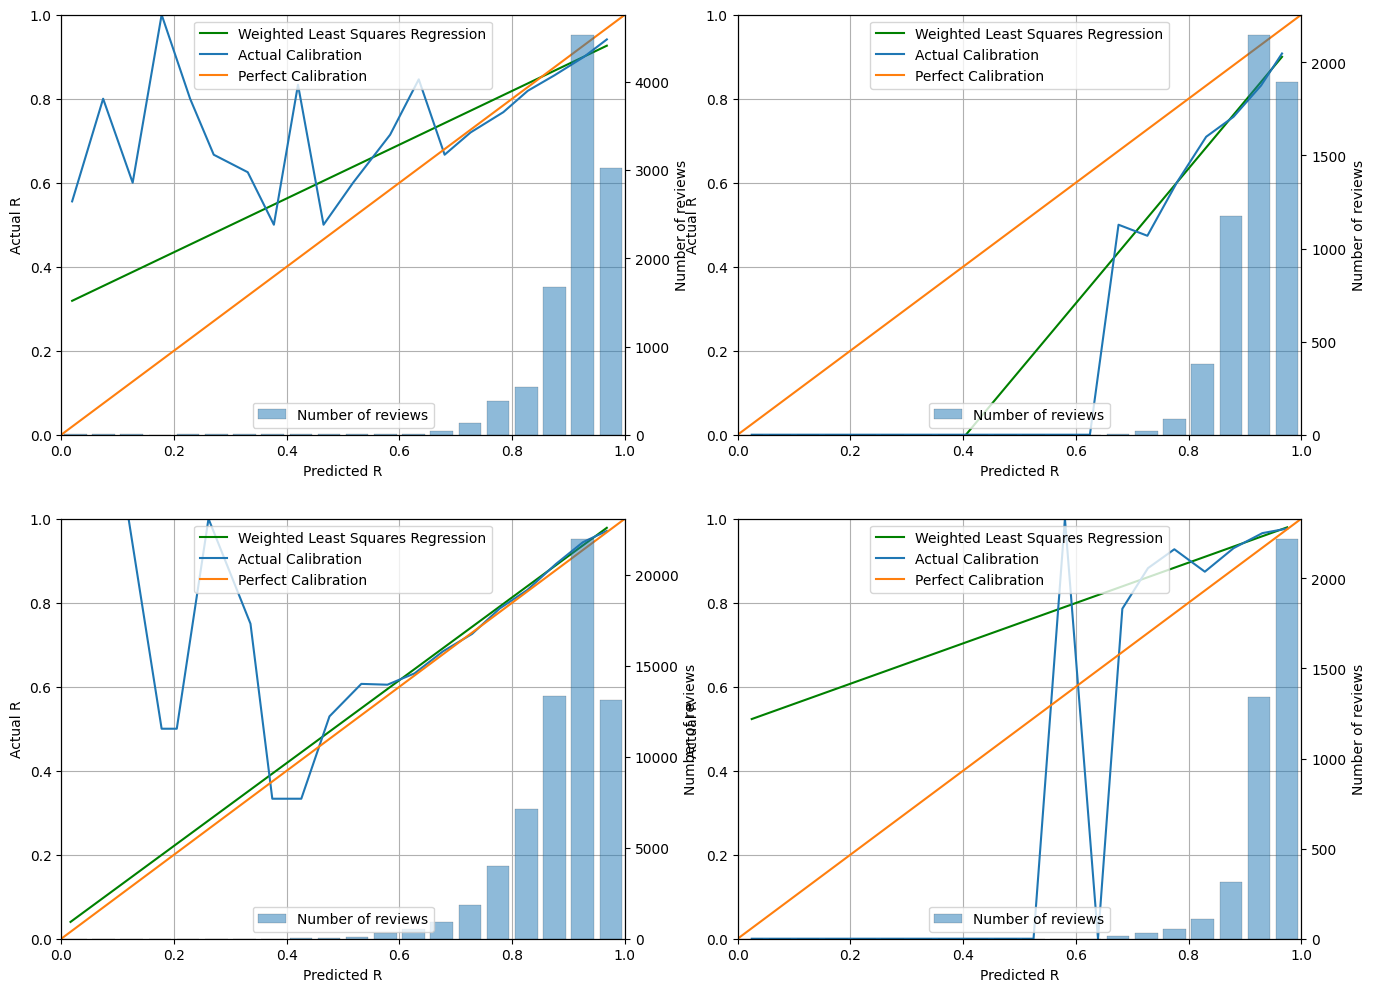

In [7]:
lr: float = 4e-2
n_epoch: int = 3
n_splits: int = 3
batch_size: int = 512
verbose: bool = False

model = FSRS3

dataset = pd.read_csv("./revlog_history.tsv", sep='\t', index_col=None, dtype={'r_history': str ,'t_history': str} )
dataset = dataset[(dataset['i'] > 1) & (dataset['delta_t'] > 0) & (dataset['t_history'].str.count(',0') == 0)]
if dataset.empty:
    raise ValueError('Training data is inadequate.')

if model == RNN:
    dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensorRNN(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)
else:
    dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensor(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)
dataset['group'] = dataset['r_history'] + dataset['t_history']
print("Tensorized!")

w = []
plots = []
if n_splits > 1:
    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    for train_index, test_index in sgkf.split(dataset, dataset['i'], dataset['group']):
        print("TRAIN:", len(train_index), "TEST:",  len(test_index))
        train_set = dataset.iloc[train_index].copy()
        test_set = dataset.iloc[test_index].copy()
        trainer = Trainer(model(), train_set, test_set, n_epoch=n_epoch, lr=lr, batch_size=batch_size)
        w.append(trainer.train(verbose=verbose))
        # plots.append(trainer.plot())
else:
    trainer = Trainer(model(), dataset, dataset, n_epoch=n_epoch, lr=lr, batch_size=batch_size)
    w.append(trainer.train(verbose=verbose))
    # plots.append(trainer.plot())

w = np.array(w)
avg_w = np.round(np.mean(w, axis=0), 4)
fsrs3_w = avg_w.tolist()

print("\nTraining finished!")

my_collection = Collection(model())
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss_before = dataset['log_loss'].mean()

my_collection = Collection(model(fsrs3_w))
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss_after = dataset['log_loss'].mean()
print(f"loss before: {loss_before:.4f}, loss after: {loss_after:.4f}, improvement: {loss_before - loss_after:.4f}")

plot_brier(dataset['p'], dataset['y'], bins=20)
plt.title("FSRS3")
plt.show()
plt.figure(figsize=(16, 12))
for last_rating in ("1","2","3","4"):
    calibration_data = dataset[dataset['r_history'].str.endswith(last_rating)]
    if calibration_data.empty:
        continue
    plt.subplot(2, 2, int(last_rating))
    print(f"\nLast rating: {last_rating}")
    plot_brier(calibration_data['p'], calibration_data['y'], bins=20)

  0%|          | 0/83598 [00:00<?, ?it/s]

Tensorized!
TRAIN: 67408 TEST: 16190
dataset built


train:   0%|          | 0/291235 [00:00<?, ?it/s]

TRAIN: 66314 TEST: 17284
dataset built


train:   0%|          | 0/299530 [00:00<?, ?it/s]

...

TRAIN: 68802 TEST: 14796
dataset built


train:   0%|          | 0/299165 [00:00<?, ?it/s]

TRAIN: 64791 TEST: 18807
dataset built


train:   0%|          | 0/299440 [00:00<?, ?it/s]


Training finished!
loss before: 0.3060, loss after: 0.3023, improvement: 0.0037
R-squared: 0.9666
RMSE: 0.0139
MAE: 0.0046
[0.04414328 0.95254382]


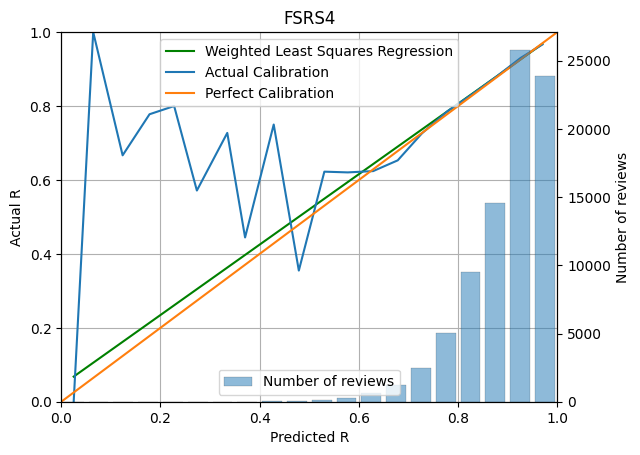


Last rating: 1
R-squared: 0.4947
RMSE: 0.0360
MAE: 0.0212
[0.30081387 0.65129474]

Last rating: 2
R-squared: 0.6477
RMSE: 0.0474
MAE: 0.0439
[0.04009621 0.90645097]

Last rating: 3
R-squared: 0.9627
RMSE: 0.0154
MAE: 0.0098
[0.01477663 0.99300776]

Last rating: 4
R-squared: 0.8112
RMSE: 0.0107
MAE: 0.0068
[0.18469463 0.80556081]


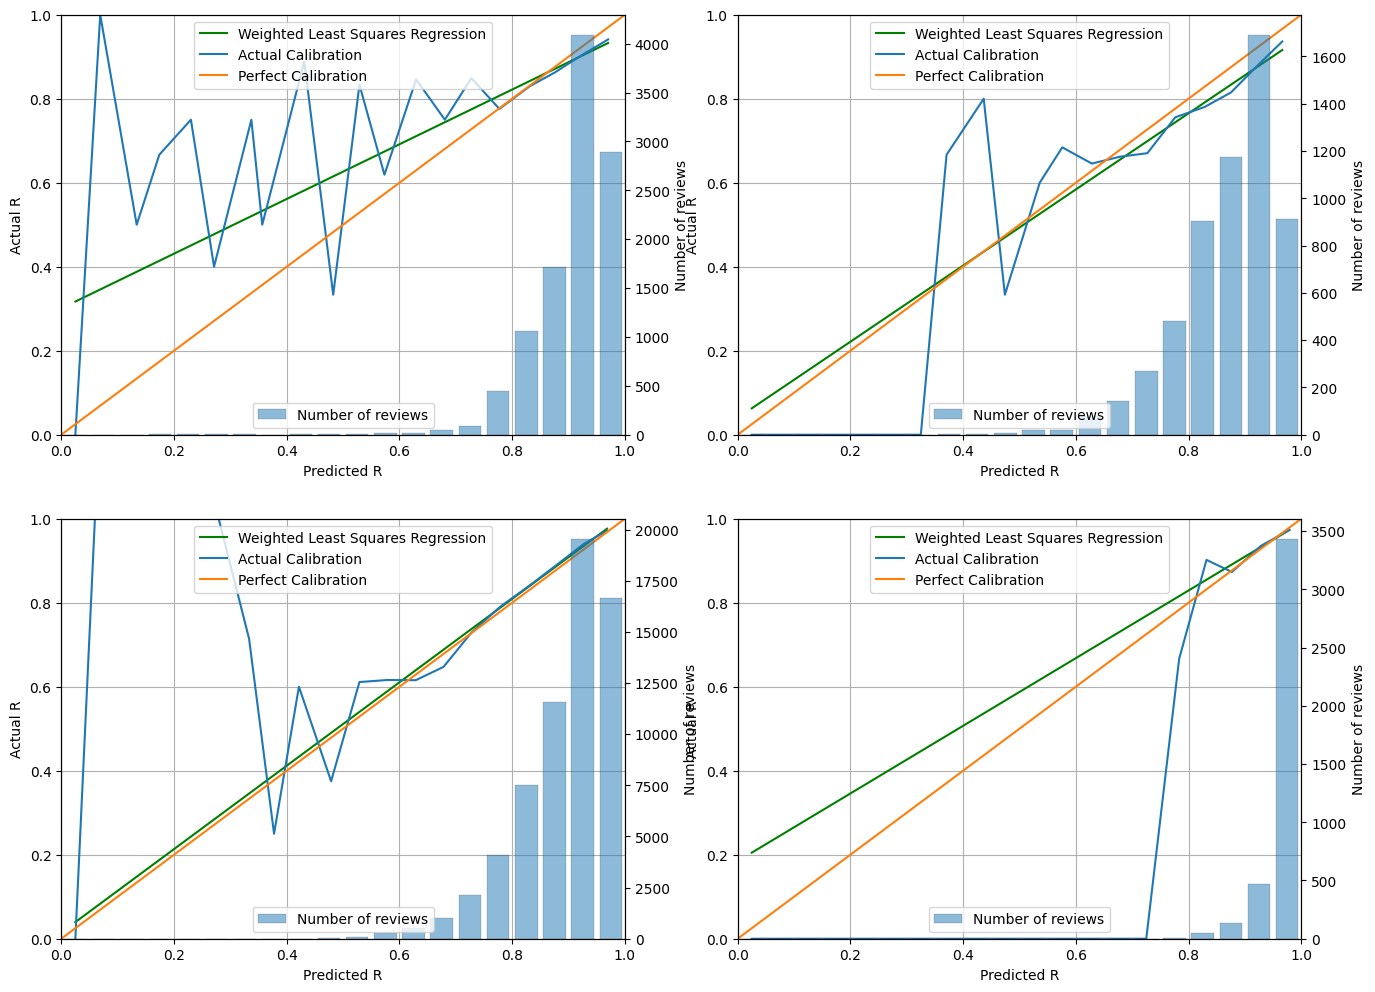

In [8]:
lr: float = 4e-2
n_epoch: int = 5
n_splits: int = 5
batch_size: int = 512
verbose: bool = False

model = FSRS4

dataset = pd.read_csv("./revlog_history.tsv", sep='\t', index_col=None, dtype={'r_history': str ,'t_history': str} )
dataset = dataset[(dataset['i'] > 1) & (dataset['delta_t'] > 0) & (dataset['t_history'].str.count(',0') == 0)]
if dataset.empty:
    raise ValueError('Training data is inadequate.')

if model == RNN:
    dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensorRNN(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)
else:
    dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensor(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)
dataset['group'] = dataset['r_history'] + dataset['t_history']
print("Tensorized!")

w = []
plots = []
if n_splits > 1:
    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    for train_index, test_index in sgkf.split(dataset, dataset['i'], dataset['group']):
        print("TRAIN:", len(train_index), "TEST:",  len(test_index))
        train_set = dataset.iloc[train_index].copy()
        test_set = dataset.iloc[test_index].copy()
        trainer = Trainer(model(), train_set, test_set, n_epoch=n_epoch, lr=lr, batch_size=batch_size)
        w.append(trainer.train(verbose=verbose))
        # plots.append(trainer.plot())
else:
    trainer = Trainer(model(), dataset, dataset, n_epoch=n_epoch, lr=lr, batch_size=batch_size)
    w.append(trainer.train(verbose=verbose))
    # plots.append(trainer.plot())


w = np.array(w)
avg_w = np.round(np.mean(w, axis=0), 4)
fsrs4_w = avg_w.tolist()

print("\nTraining finished!")

my_collection = Collection(model())
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss_before = dataset['log_loss'].mean()

my_collection = Collection(model(fsrs4_w))
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss_after = dataset['log_loss'].mean()
print(f"loss before: {loss_before:.4f}, loss after: {loss_after:.4f}, improvement: {loss_before - loss_after:.4f}")

plot_brier(dataset['p'], dataset['y'], bins=20)
plt.title("FSRS4")
plt.show()
plt.figure(figsize=(16, 12))
for last_rating in ("1","2","3","4"):
    calibration_data = dataset[dataset['r_history'].str.endswith(last_rating)]
    if calibration_data.empty:
        continue
    plt.subplot(2, 2, int(last_rating))
    print(f"\nLast rating: {last_rating}")
    plot_brier(calibration_data['p'], calibration_data['y'], bins=20)

Loss: 0.3833
R-squared: -6.6023
RMSE: 0.1426
MAE: 0.0762
[0.67448088 0.26770332]


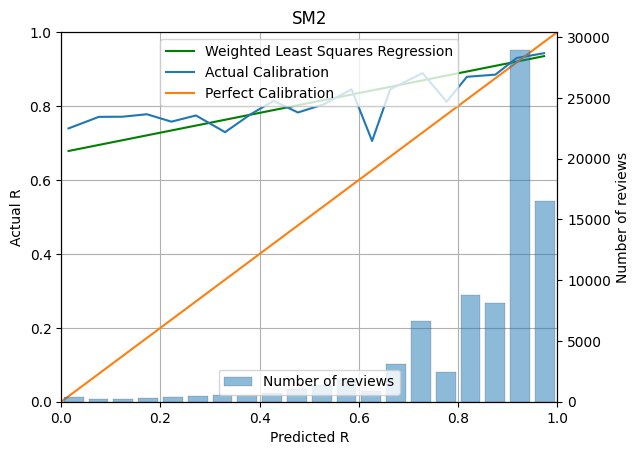


Last rating: 1
R-squared: -12.0028
RMSE: 0.1746
MAE: 0.1108
[0.6873516  0.26064155]

Last rating: 2
R-squared: -1.2567
RMSE: 0.1027
MAE: 0.0867
[0.42583227 0.44938713]

Last rating: 3
R-squared: -4.5974
RMSE: 0.1376
MAE: 0.0712
[0.65020218 0.2981828 ]

Last rating: 4
R-squared: -129.7130
RMSE: 0.2312
MAE: 0.1826
[0.91136633 0.06767175]


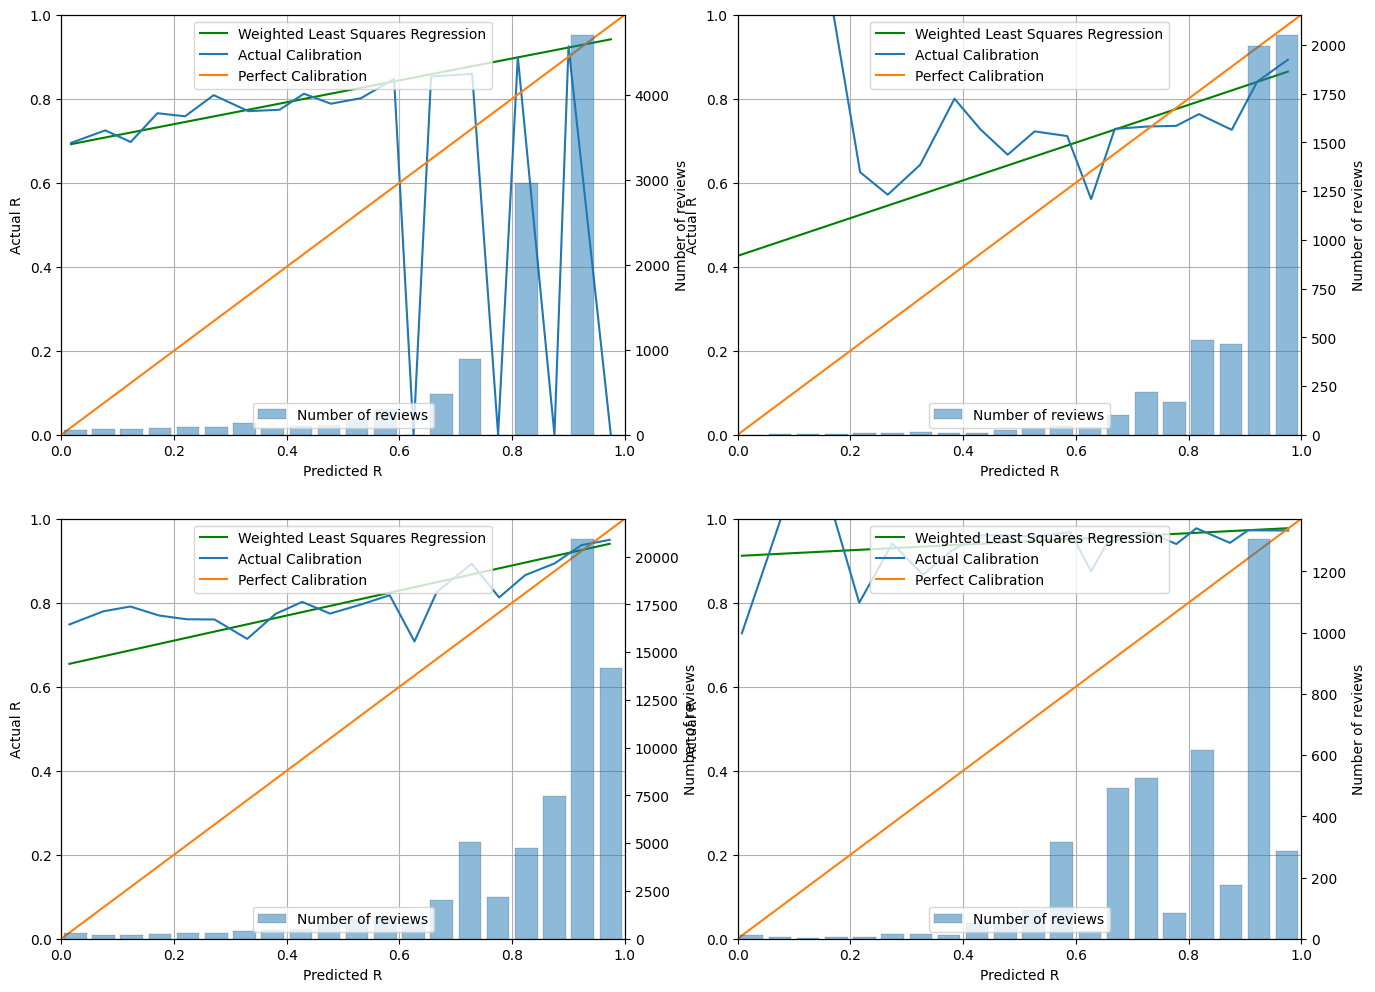

In [9]:
def sm2(history):
    ivl = 0
    ef = 2.5
    reps = 0
    for delta_t, rating in history:
        delta_t = delta_t.item()
        rating = rating.item() + 1
        if rating > 2:
            if reps == 0:
                ivl = 1
                reps = 1
            elif reps == 1:
                ivl = 6
                reps = 2
            else:
                ivl = ivl * ef
                reps += 1
        else:
            ivl = 1
            reps = 0
        ef = max(1.3, ef + (0.1 - (5 - rating) * (0.08 + (5 - rating) * 0.02)))
        ivl = max(1, round(ivl+0.01))
    return ivl


dataset['stability'] = dataset['tensor'].map(sm2)
dataset['p'] = np.exp(np.log(0.9) * dataset['delta_t'] / dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss = dataset['log_loss'].mean()
print(f"Loss: {loss:.4f}")

plot_brier(dataset['p'], dataset['y'], bins=20)
plt.title("SM2")
plt.show()
plt.figure(figsize=(16, 12))
for last_rating in ("1","2","3","4"):
    calibration_data = dataset[dataset['r_history'].str.endswith(last_rating)]
    if calibration_data.empty:
        continue
    plt.subplot(2, 2, int(last_rating))
    print(f"\nLast rating: {last_rating}")
    plot_brier(calibration_data['p'], calibration_data['y'], bins=20)

Loss: 0.4425
R-squared: -20.1601
RMSE: 0.0986
MAE: 0.0745
[0.88117736 0.01759118]


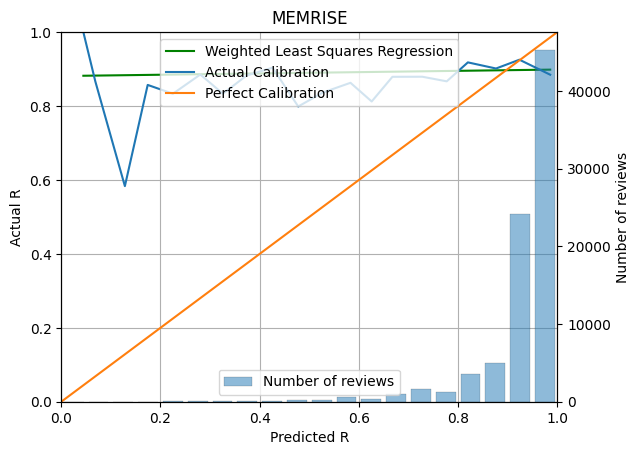


Last rating: 1
R-squared: -41.8629
RMSE: 0.0931
MAE: 0.0868
[0.73746789 0.15755801]

Last rating: 2
R-squared: -60.4105
RMSE: 0.1384
MAE: 0.1327
[0.73934708 0.09323276]

Last rating: 3
R-squared: -8.4604
RMSE: 0.0879
MAE: 0.0655
[0.78986026 0.11889118]

Last rating: 4
R-squared: -115.8343
RMSE: 0.2149
MAE: 0.1731
[ 1.01803318 -0.06629349]


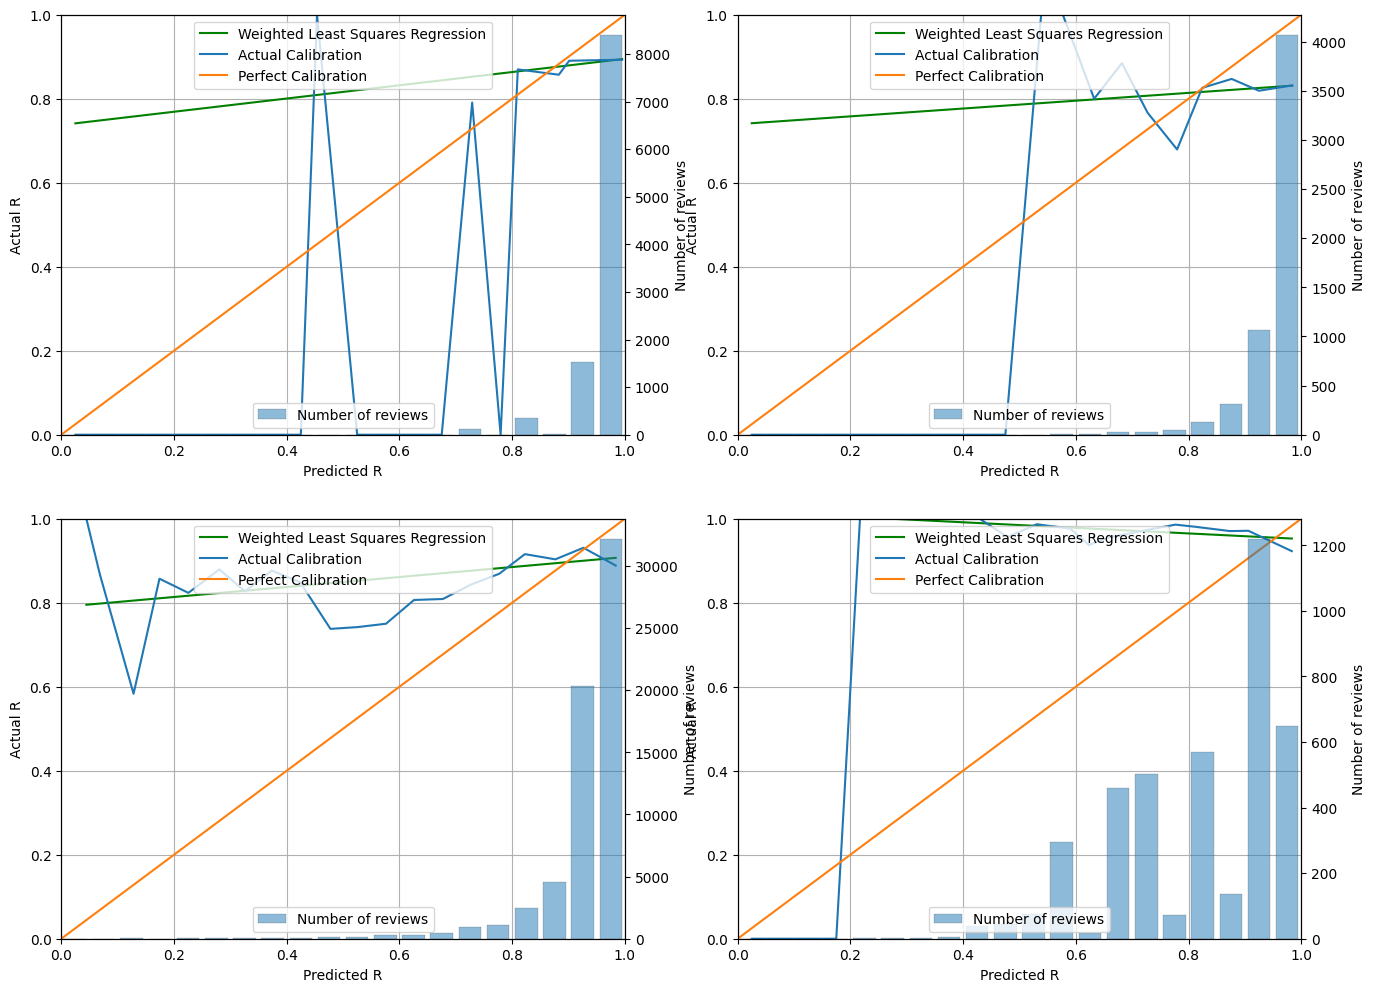

In [10]:
def memrise(history):
    ivl = 0
    reps = 0
    for delta_t, rating in history:
        delta_t = delta_t.item()
        rating = rating.item() + 1
        intervals = [1, 6, 12, 24, 48, 96, 180]
        if rating > 1:
            reps += 1
            if reps > 7:
                reps = 7
            ivl = intervals[reps-1]
        else:
            ivl = 1
            reps = 1
    return ivl

dataset['stability'] = dataset['tensor'].map(memrise)
dataset['p'] = np.exp(np.log(0.9) * dataset['delta_t'] / dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss = dataset['log_loss'].mean()
print(f"Loss: {loss:.4f}")
plot_brier(dataset['p'], dataset['y'], bins=20)
plt.title("MEMRISE")
plt.show()
plt.figure(figsize=(16, 12))
for last_rating in ("1","2","3","4"):
    calibration_data = dataset[dataset['r_history'].str.endswith(last_rating)]
    if calibration_data.empty:
        continue
    plt.subplot(2, 2, int(last_rating))
    print(f"\nLast rating: {last_rating}")
    plot_brier(calibration_data['p'], calibration_data['y'], bins=20)

In [11]:
dataset = pd.read_csv("./revlog_history.tsv", sep='\t', index_col=None, dtype={'r_history': str ,'t_history': str} )
dataset = dataset[(dataset['i'] > 1) & (dataset['delta_t'] > 0) & (dataset['t_history'].str.count(',0') == 0)]
dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensor(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)

my_collection = Collection(FSRS4(fsrs4_w))
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['FSRS4_p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])

my_collection = Collection(FSRS3(fsrs3_w))
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['FSRS3_p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])

dataset['stability'] = dataset['tensor'].map(sm2)
dataset['SM2_p'] = np.exp(np.log(0.9) * dataset['delta_t'] / dataset['stability'])

dataset['stability'] = dataset['tensor'].map(memrise)
dataset['MEMRISE_p'] = np.exp(np.log(0.9) * dataset['delta_t'] / dataset['stability'])

dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensorRNN(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)

my_collection = Collection(RNN(lstm_w))
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['LSTM_p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])

cross_comparison = dataset[['FSRS4_p', 'FSRS3_p', 'LSTM_p', 'SM2_p', 'MEMRISE_p', 'y']].copy()
cross_comparison['FSRS4_bw'] = cross_comparison['FSRS4_p'] - cross_comparison['y']
cross_comparison['FSRS4_bin'] = cross_comparison['FSRS4_p'].map(lambda x: round(x * 2, 1) / 2)
cross_comparison['FSRS3_bw'] = cross_comparison['FSRS3_p'] - cross_comparison['y']
cross_comparison['FSRS3_bin'] = cross_comparison['FSRS3_p'].map(lambda x: round(x * 2, 1) / 2)
cross_comparison['LSTM_bw'] = cross_comparison['LSTM_p'] - cross_comparison['y']
cross_comparison['LSTM_bin'] = cross_comparison['LSTM_p'].map(lambda x: round(x * 2, 1) / 2)
cross_comparison['SM2_bw'] = cross_comparison['SM2_p'] - cross_comparison['y']
cross_comparison['SM2_bin'] = cross_comparison['SM2_p'].map(lambda x: round(x * 2, 1) / 2)
cross_comparison['MEMRISE_bw'] = cross_comparison['MEMRISE_p'] - cross_comparison['y']
cross_comparison['MEMRISE_bin'] = cross_comparison['MEMRISE_p'].map(lambda x: round(x * 2, 1) / 2)

  0%|          | 0/83598 [00:00<?, ?it/s]

  0%|          | 0/83598 [00:00<?, ?it/s]

Universal Metric of FSRS3: 0.0181
Universal Metric of FSRS4: 0.0149


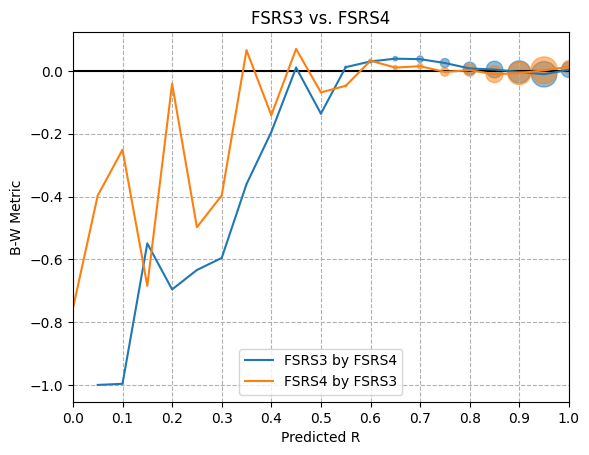

In [12]:
plt.axhline(y = 0.0, color = 'black', linestyle = '-')

classifier = 'FSRS4'
predicter = 'FSRS3'

cross_comparison_group = cross_comparison.groupby(by=f'{classifier}_bin').agg({'y': ['mean'], f'{predicter}_bw': ['mean'], f'{predicter}_p': ['mean', 'count']})
print(f"Universal Metric of {predicter}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{predicter}_p', 'mean'], sample_weight=cross_comparison_group[f'{predicter}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{classifier}_p', 'percent'] = cross_comparison_group[f'{predicter}_p', 'count'] / cross_comparison_group[f'{predicter}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{predicter}_bw', 'mean'], s=cross_comparison_group[f'{classifier}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{predicter}_bw', 'mean'], label=f'{predicter} by {classifier}')

cross_comparison_group = cross_comparison.groupby(by=f'{predicter}_bin').agg({'y': ['mean'], f'{classifier}_bw': ['mean'], f'{classifier}_p': ['mean', 'count']})
print(f"Universal Metric of {classifier}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{classifier}_p', 'mean'], sample_weight=cross_comparison_group[f'{classifier}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{predicter}_p', 'percent'] = cross_comparison_group[f'{classifier}_p', 'count'] / cross_comparison_group[f'{classifier}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{classifier}_bw', 'mean'], s=cross_comparison_group[f'{predicter}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{classifier}_bw', 'mean'], label=f'{classifier} by {predicter}')

plt.legend(loc='lower center')
plt.grid(linestyle='--')
plt.title(f"{predicter} vs. {classifier}")
plt.xlabel('Predicted R')
plt.ylabel('B-W Metric')
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.show()

Universal Metric of LSTM: 0.0157
Universal Metric of FSRS4: 0.0169


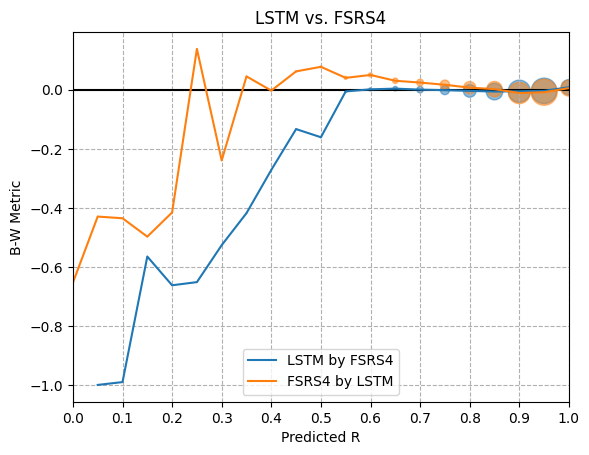

In [13]:
plt.axhline(y = 0.0, color = 'black', linestyle = '-')

classifier = 'FSRS4'
predicter = 'LSTM'

cross_comparison_group = cross_comparison.groupby(by=f'{classifier}_bin').agg({'y': ['mean'], f'{predicter}_bw': ['mean'], f'{predicter}_p': ['mean', 'count']})
print(f"Universal Metric of {predicter}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{predicter}_p', 'mean'], sample_weight=cross_comparison_group[f'{predicter}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{classifier}_p', 'percent'] = cross_comparison_group[f'{predicter}_p', 'count'] / cross_comparison_group[f'{predicter}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{predicter}_bw', 'mean'], s=cross_comparison_group[f'{classifier}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{predicter}_bw', 'mean'], label=f'{predicter} by {classifier}')

cross_comparison_group = cross_comparison.groupby(by=f'{predicter}_bin').agg({'y': ['mean'], f'{classifier}_bw': ['mean'], f'{classifier}_p': ['mean', 'count']})
print(f"Universal Metric of {classifier}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{classifier}_p', 'mean'], sample_weight=cross_comparison_group[f'{classifier}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{predicter}_p', 'percent'] = cross_comparison_group[f'{classifier}_p', 'count'] / cross_comparison_group[f'{classifier}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{classifier}_bw', 'mean'], s=cross_comparison_group[f'{predicter}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{classifier}_bw', 'mean'], label=f'{classifier} by {predicter}')

plt.legend(loc='lower center')
plt.grid(linestyle='--')
plt.title(f"{predicter} vs. {classifier}")
plt.xlabel('Predicted R')
plt.ylabel('B-W Metric')
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.show()

Universal Metric of SM2: 0.0683
Universal Metric of FSRS4: 0.0098


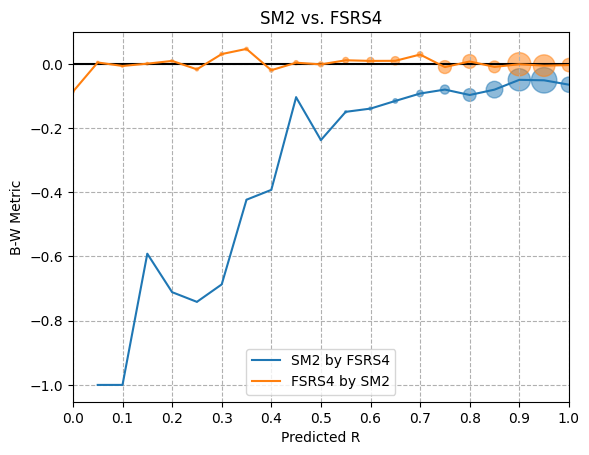

In [14]:
plt.axhline(y = 0.0, color = 'black', linestyle = '-')

classifier = 'FSRS4'
predicter = 'SM2'

cross_comparison_group = cross_comparison.groupby(by=f'{classifier}_bin').agg({'y': ['mean'], f'{predicter}_bw': ['mean'], f'{predicter}_p': ['mean', 'count']})
print(f"Universal Metric of {predicter}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{predicter}_p', 'mean'], sample_weight=cross_comparison_group[f'{predicter}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{classifier}_p', 'percent'] = cross_comparison_group[f'{predicter}_p', 'count'] / cross_comparison_group[f'{predicter}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{predicter}_bw', 'mean'], s=cross_comparison_group[f'{classifier}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{predicter}_bw', 'mean'], label=f'{predicter} by {classifier}')

cross_comparison_group = cross_comparison.groupby(by=f'{predicter}_bin').agg({'y': ['mean'], f'{classifier}_bw': ['mean'], f'{classifier}_p': ['mean', 'count']})
print(f"Universal Metric of {classifier}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{classifier}_p', 'mean'], sample_weight=cross_comparison_group[f'{classifier}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{predicter}_p', 'percent'] = cross_comparison_group[f'{classifier}_p', 'count'] / cross_comparison_group[f'{classifier}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{classifier}_bw', 'mean'], s=cross_comparison_group[f'{predicter}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{classifier}_bw', 'mean'], label=f'{classifier} by {predicter}')

plt.legend(loc='lower center')
plt.grid(linestyle='--')
plt.title(f"{predicter} vs. {classifier}")
plt.xlabel('Predicted R')
plt.ylabel('B-W Metric')
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.show()

Universal Metric of MEMRISE: 0.0826
Universal Metric of FSRS4: 0.0095


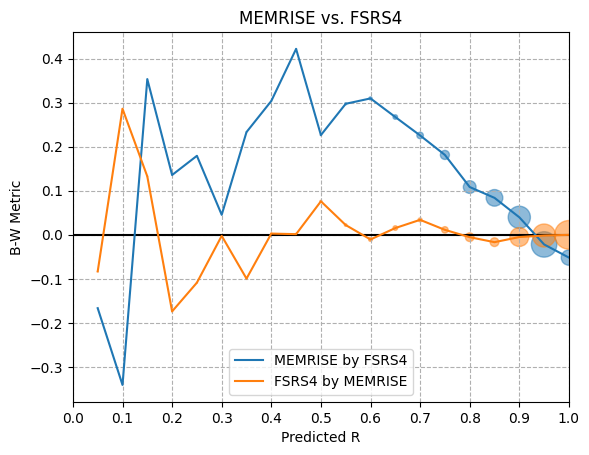

In [15]:
plt.axhline(y = 0.0, color = 'black', linestyle = '-')

classifier = 'FSRS4'
predicter = 'MEMRISE'

cross_comparison_group = cross_comparison.groupby(by=f'{classifier}_bin').agg({'y': ['mean'], f'{predicter}_bw': ['mean'], f'{predicter}_p': ['mean', 'count']})
print(f"Universal Metric of {predicter}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{predicter}_p', 'mean'], sample_weight=cross_comparison_group[f'{predicter}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{classifier}_p', 'percent'] = cross_comparison_group[f'{predicter}_p', 'count'] / cross_comparison_group[f'{predicter}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{predicter}_bw', 'mean'], s=cross_comparison_group[f'{classifier}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{predicter}_bw', 'mean'], label=f'{predicter} by {classifier}')

cross_comparison_group = cross_comparison.groupby(by=f'{predicter}_bin').agg({'y': ['mean'], f'{classifier}_bw': ['mean'], f'{classifier}_p': ['mean', 'count']})
print(f"Universal Metric of {classifier}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{classifier}_p', 'mean'], sample_weight=cross_comparison_group[f'{classifier}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{predicter}_p', 'percent'] = cross_comparison_group[f'{classifier}_p', 'count'] / cross_comparison_group[f'{classifier}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{classifier}_bw', 'mean'], s=cross_comparison_group[f'{predicter}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{classifier}_bw', 'mean'], label=f'{classifier} by {predicter}')

plt.legend(loc='lower center')
plt.grid(linestyle='--')
plt.title(f"{predicter} vs. {classifier}")
plt.xlabel('Predicted R')
plt.ylabel('B-W Metric')
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.show()